## Inwiefern führt die Stuktur von Wikidata zu einer Unterrepräsentation alltäglicher Berufe und welche geschlechtsspezifischen Verzerrungen ergeben sich daraus?

In dieser Analyse wird untersucht, wie Männer und Frauen in verschiedenen Berufsgruppen in Wikidata vertreten sind. Zunächst wird die Geschlechterverteilung innerhalb ausgewählter Berufe analysiert. Anschließend soll diese Verteilung mit realen Arbeitsmarktdaten verglichen werden. 

### Geschlechterverteilung innerhalb ausgewählter Berufe

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [15]:
pfad = "../data"

aerzte = pd.read_csv(os.path.join(pfad, "aerzte_geschlechtsverteilung.csv"))
beamte = pd.read_csv(os.path.join(pfad, "beamte_geschlechtsverteilung.csv"))
buero = pd.read_csv(os.path.join(pfad, "bueroangestellte_geschlechtsverteilung.csv"))
ceo = pd.read_csv(os.path.join(pfad, "ceo_geschlechtsverteilung.csv"))
erzieher = pd.read_csv(os.path.join(pfad, "erzieher_geschlechtsverteilung.csv"))
lehrer = pd.read_csv(os.path.join(pfad, "lehrer_geschlechtsverteilung.csv"))
pflege = pd.read_csv(os.path.join(pfad, "pflegefachkraft_geschlechtsverteilung.csv"))
politiker = pd.read_csv(os.path.join(pfad, "politiker_geschlechtsverteilung.csv"))

In [16]:
aerzte["beruf"] = "Ärzte"
beamte["beruf"] = "Beamte"
buero["beruf"] = "Büroangestellte"
ceo["beruf"] = "CEO"
erzieher["beruf"] = "Erzieher"
lehrer["beruf"] = "Lehrer"
pflege["beruf"] = "Pflegefachkräfte"
politiker["beruf"] = "Politiker"

In [23]:
alle_berufe = pd.concat([
    aerzte,
    pflege,
    ceo,
    buero,
    lehrer,
    erzieher,
    politiker,
    beamte
])


In [24]:
gesamt_pro_beruf = alle_berufe.groupby("beruf")["count"].transform("sum")

alle_berufe["anteil_prozent"] = (
    alle_berufe["count"] / gesamt_pro_beruf * 100
).round(2)

alle_berufe

,genderLabel,count,beruf,anteil_prozent
0,männlich,5222,Ärzte,91.71
1,weiblich,472,Ärzte,8.29
0,weiblich,208,Pflegefachkräfte,79.69
1,männlich,53,Pflegefachkräfte,20.31
0,männlich,103,CEO,91.96
1,weiblich,9,CEO,8.04
0,weiblich,7,Büroangestellte,53.85
1,männlich,6,Büroangestellte,46.15
0,männlich,3589,Lehrer,78.69
1,weiblich,972,Lehrer,21.31


In [38]:
plot_df = alle_berufe[
    alle_berufe["genderLabel"].isin(["männlich", "weiblich"])
]

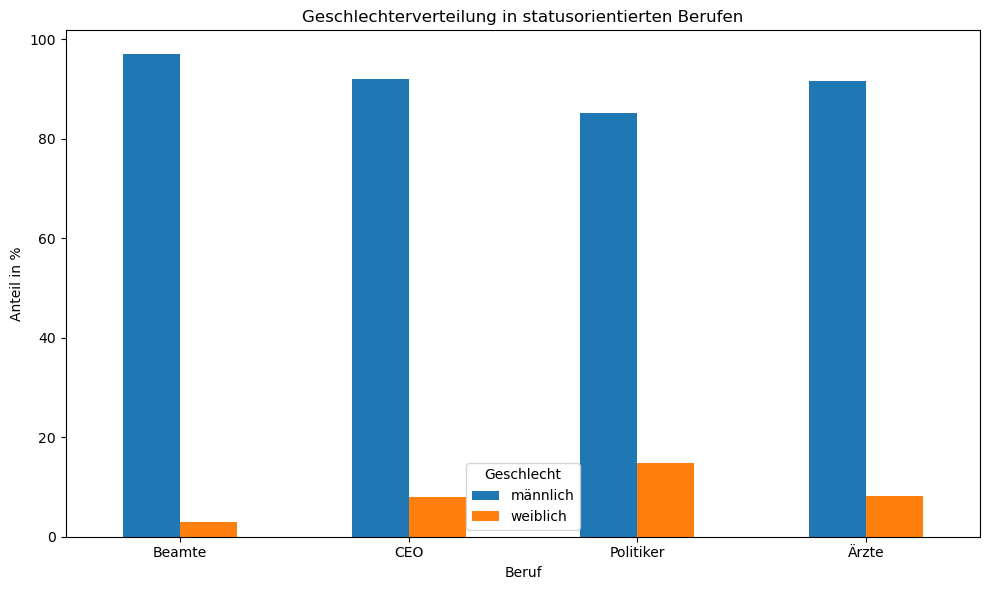

In [37]:
statusberufe = plot_df[
    plot_df["beruf"].isin([
        "CEO",
        "Ärzte",
        "Beamte",
        "Politiker"
    ])
]

pivot_status = statusberufe.pivot(
    index="beruf",
    columns="genderLabel",
    values="anteil_prozent"
)

pivot_status.plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Anteil in %")
plt.xlabel("Beruf")

plt.title(
    "Geschlechterverteilung in statusorientierten Berufen"
)

plt.xticks(rotation=0)

plt.legend(title="Geschlecht")

plt.tight_layout()
plt.show()

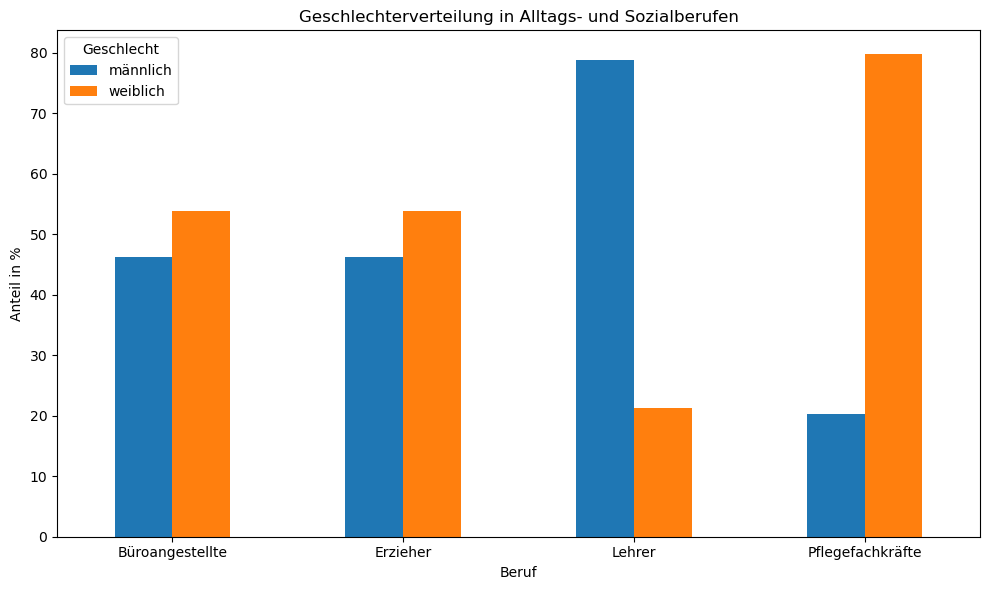

In [36]:
alltagsberufe = plot_df[
    plot_df["beruf"].isin([
        "Erzieher",
        "Lehrer",
        "Pflegefachkräfte",
        "Büroangestellte"
    ])
]

pivot_alltag = alltagsberufe.pivot(
    index="beruf",
    columns="genderLabel",
    values="anteil_prozent"
)

pivot_alltag.plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Anteil in %")
plt.xlabel("Beruf")

plt.title(
    "Geschlechterverteilung in Alltags- und Sozialberufen"
)

plt.xticks(rotation=0)

plt.legend(title="Geschlecht")

plt.tight_layout()
plt.show()

Die Grafik zeigt deutlich Unterschiede zwischen den untersuchten Berufsgruppen. Während Berufe wie CEO, Politiker oder Beamte in Wikidata überwiegend männlich geprägt sind, weisen soziale Berufe wie Erzieher oder Pflegefachkräfte einen deutlich höheren Frauenanteil auf. Damit spiegeln die Daten teilweise traditionelle Geschlechterrollen wider. Gleichzeitig ist zu beachten, dass Wikidata keine vollständige Abbildung der realen Berufsstruktur darstellt, sondern vor allem Personen enthält, die als relevant genug für einen Eintrag gelten. 

### Vergleich mit realen Arbeitsmarktdaten

Im folgenden Abschnitt wird die Geschlechterverteilung in Wikidata mit realen Arbeitsmarktdaten verglichen. Dadurch soll untersucht werden, ob bestimmte Berufsgruppen auf Wikidata stärker männlich oder weiblich dargestellt werden als in der Realität.

In [27]:
aerzte_real = pd.read_csv(
    os.path.join(pfad, "aerzte_reale_daten.csv")
)

beamte_real = pd.read_csv(
    os.path.join(pfad, "beamte_reale_daten.csv")
)

buero_real = pd.read_csv(
    os.path.join(pfad, "bueroangestellte_reale_daten.csv")
)

ceo_real = pd.read_csv(
    os.path.join(pfad, "ceo_reale_daten.csv")
)

erzieher_real = pd.read_csv(
    os.path.join(pfad, "erzieher_reale_daten.csv")
)

lehrer_real = pd.read_csv(
    os.path.join(pfad, "lehrer_reale_daten.csv")
)

pflege_real = pd.read_csv(
    os.path.join(pfad, "pflegefachkraft_reale_daten.csv")
)

politiker_real = pd.read_csv(
    os.path.join(pfad, "politiker_reale_daten.csv")
)

In [28]:
aerzte_real["beruf"] = "Ärzte"
beamte_real["beruf"] = "Beamte"
buero_real["beruf"] = "Büroangestellte"
ceo_real["beruf"] = "CEO"
erzieher_real["beruf"] = "Erzieher"
lehrer_real["beruf"] = "Lehrer"
pflege_real["beruf"] = "Pflegefachkräfte"
politiker_real["beruf"] = "Politiker"

In [31]:
reale_daten = pd.concat([
    aerzte_real,
    beamte_real,
    buero_real,
    ceo_real,
    erzieher_real,
    lehrer_real,
    pflege_real,
    politiker_real
])

reale_daten = reale_daten.rename(
    columns={
        "count": "anteil_prozent"
    }
)

reale_daten

,genderLabel,anteil_prozent,beruf
0,männlich,49.77,Ärzte
1,weiblich,50.23,Ärzte
0,männlich,45.45,Beamte
1,weiblich,54.55,Beamte
0,männlich,34.40,Büroangestellte
1,weiblich,65.60,Büroangestellte
0,männlich,71.05,CEO
1,weiblich,28.95,CEO
0,männlich,8.10,Erzieher
1,weiblich,91.90,Erzieher


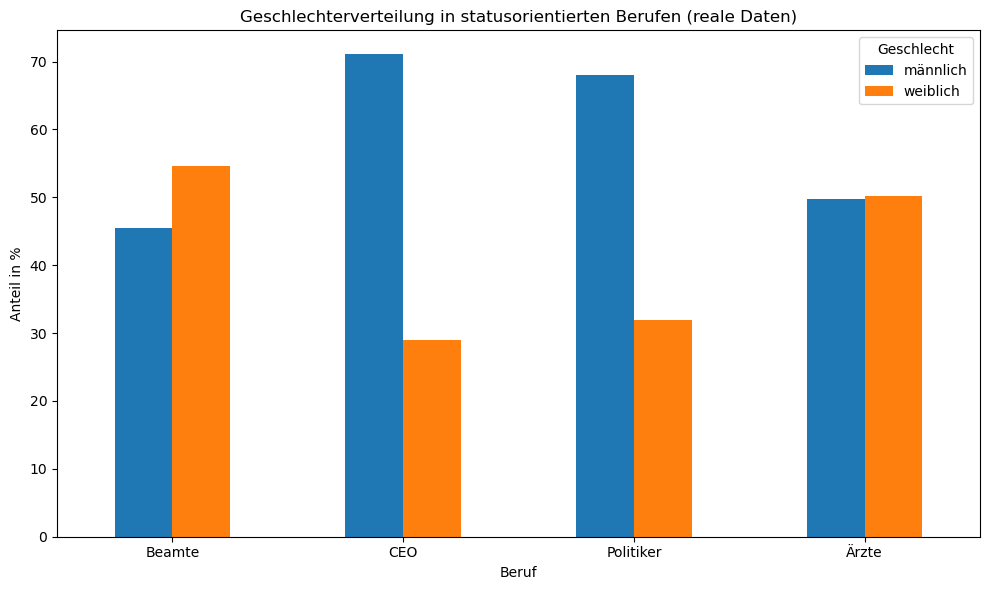

In [39]:
statusberufe_real = reale_daten[
    reale_daten["beruf"].isin([
        "CEO",
        "Ärzte",
        "Beamte",
        "Politiker"
    ])
]

pivot_status_real = statusberufe_real.pivot(
    index="beruf",
    columns="genderLabel",
    values="anteil_prozent"
)

pivot_status_real.plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Anteil in %")
plt.xlabel("Beruf")

plt.title(
    "Geschlechterverteilung in statusorientierten Berufen (reale Daten)"
)

plt.xticks(rotation=0)

plt.legend(title="Geschlecht")

plt.tight_layout()
plt.show()

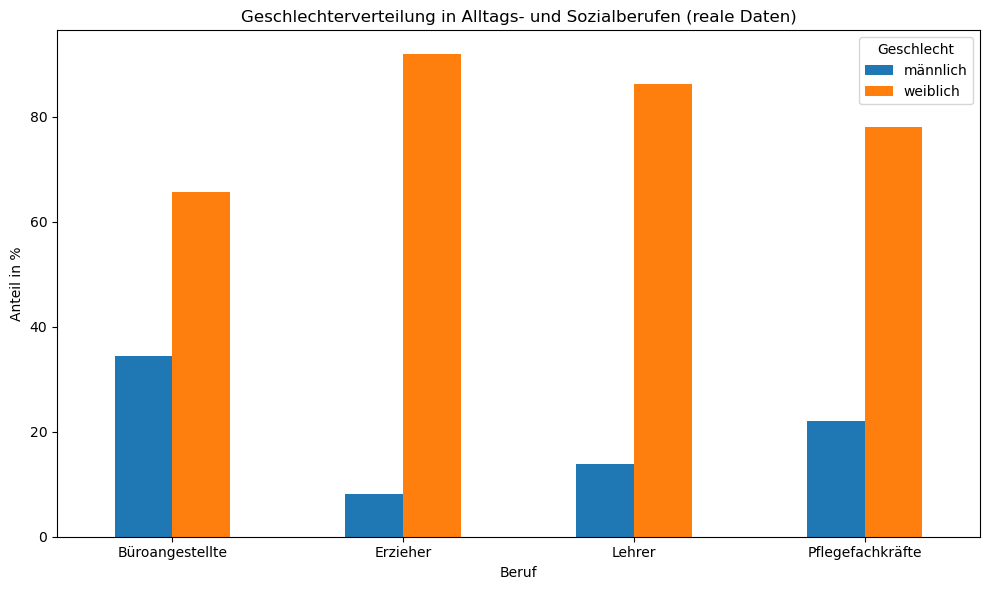

In [40]:
alltagsberufe_real = reale_daten[
    reale_daten["beruf"].isin([
        "Erzieher",
        "Lehrer",
        "Pflegefachkräfte",
        "Büroangestellte"
    ])
]

pivot_alltag_real = alltagsberufe_real.pivot(
    index="beruf",
    columns="genderLabel",
    values="anteil_prozent"
)

pivot_alltag_real.plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Anteil in %")
plt.xlabel("Beruf")

plt.title(
    "Geschlechterverteilung in Alltags- und Sozialberufen (reale Daten)"
)

plt.xticks(rotation=0)

plt.legend(title="Geschlecht")

plt.tight_layout()
plt.show()

In [32]:
wikidata_frauen = alle_berufe[
    alle_berufe["genderLabel"] == "weiblich"
][["beruf", "anteil_prozent"]]

wikidata_frauen = wikidata_frauen.rename(
    columns={
        "anteil_prozent": "wikidata"
    }
)

real_frauen = reale_daten[
    reale_daten["genderLabel"] == "weiblich"
][["beruf", "anteil_prozent"]]

real_frauen = real_frauen.rename(
    columns={
        "anteil_prozent": "real"
    }
)

In [33]:
vergleich = pd.merge(
    wikidata_frauen,
    real_frauen,
    on="beruf"
)

vergleich

,beruf,wikidata,real
0,Ärzte,8.29,50.23
1,Pflegefachkräfte,79.69,78.00
2,CEO,8.04,28.95
3,Büroangestellte,53.85,65.60
4,Lehrer,21.31,86.20
5,Erzieher,53.85,91.90
6,Politiker,14.84,32.00
7,Beamte,3.01,54.55


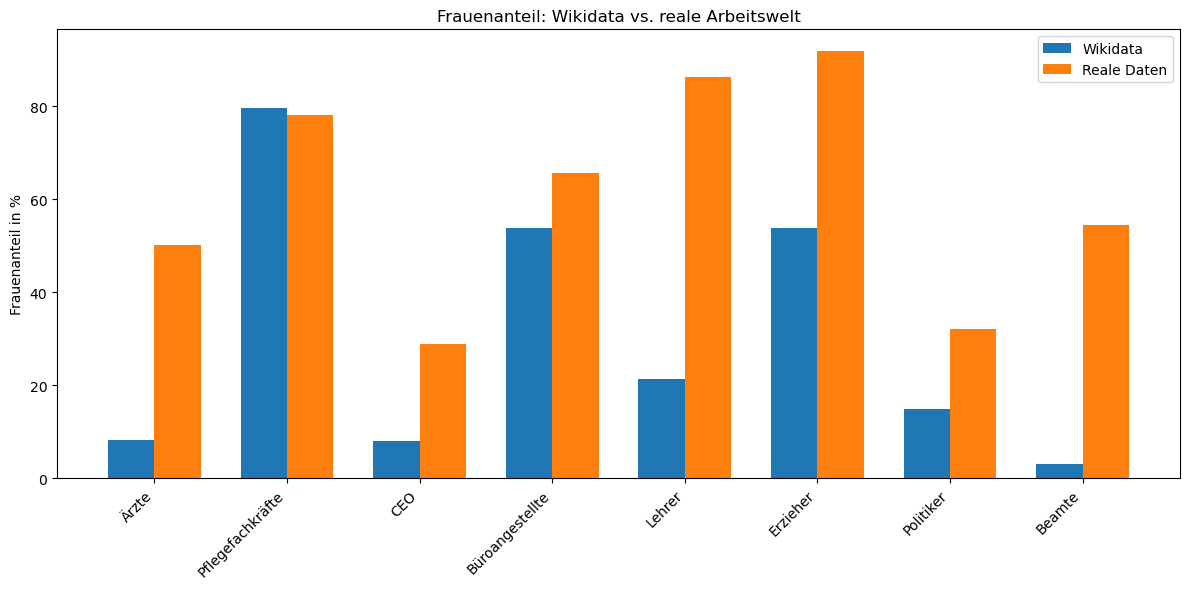

In [34]:
import numpy as np

x = np.arange(len(vergleich["beruf"]))
breite = 0.35

fig, ax = plt.subplots(figsize=(12,6))

ax.bar(
    x - breite/2,
    vergleich["wikidata"],
    breite,
    label="Wikidata"
)

ax.bar(
    x + breite/2,
    vergleich["real"],
    breite,
    label="Reale Daten"
)

ax.set_xticks(x)

ax.set_xticklabels(
    vergleich["beruf"],
    rotation=45,
    ha="right"
)

ax.set_ylabel("Frauenanteil in %")

ax.set_title(
    "Frauenanteil: Wikidata vs. reale Arbeitswelt"
)

ax.legend()

plt.tight_layout()
plt.show()